# 🚀**NSLKDD MULTI-CLASS CLASSIFICTION**

1. Import the Libraries

In [3]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report
from sklearn.feature_selection import RFE
import itertools
import time
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from xgboost import XGBClassifier

2. Load Data

In [4]:
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

train=pd.read_csv("/content/drive/MyDrive/KDDTrain+_20Percent.txt",names=col_names)
test=pd.read_csv("/content/drive/MyDrive/KDDTest-21.txt",names=col_names)
train.drop(['difficulty'], axis=1, inplace=True)
test.drop(['difficulty'], axis=1, inplace=True)


3. Shape of the Data

In [5]:
print("---Training Data---")
print(f"Shape: {train.shape}")
print("\n---Test Data---")
print(f"Shape: {test.shape}")

---Training Data---
Shape: (25192, 42)

---Test Data---
Shape: (11850, 42)


In [6]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


4. Data info

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  object 
 2   service                      25192 non-null  object 
 3   flag                         25192 non-null  object 
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised              25192 non-null  int64  
 13  root_shell      

5. Check for missing values

In [8]:
train.isnull().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [9]:
print("Total missing values:",train.isnull().sum().sum())
train=train.dropna()

Total missing values: 0


6. Statistical Information of Data

In [10]:
train.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,25192.000000,2.519200e+04,2.519200e+04,25192.000000,25192.000000,25192.00000,25192.000000,25192.000000,25192.000000,25192.000000,...,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000
mean,305.054104,2.433063e+04,3.491847e+03,0.000079,0.023738,0.00004,0.198039,0.001191,0.394768,0.227850,...,182.532074,115.063036,0.519791,0.082539,0.147453,0.031844,0.285800,0.279846,0.117800,0.118769
std,2686.555640,2.410805e+06,8.883072e+04,0.008910,0.260221,0.00630,2.154202,0.045418,0.488811,10.417352,...,98.993895,110.646850,0.448944,0.187191,0.308367,0.110575,0.445316,0.446075,0.305869,0.317333
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,84.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,255.000000,61.000000,0.510000,0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.790000e+02,5.302500e+02,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42862.000000,3.817091e+08,5.151385e+06,1.000000,3.000000,1.00000,77.000000,4.000000,1.000000,884.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


7. Remove Duplicates

In [11]:
print("Before removing duplicates:", train.shape)
train = train.drop_duplicates()
print("After removing duplicates:", train.shape)

Before removing duplicates: (25192, 42)
After removing duplicates: (25192, 42)


8. Top 10 types of Attacks

/tmp/ipython-input-4175320351.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_attacks, order=df_attacks.value_counts().index[1:11], palette="magma")


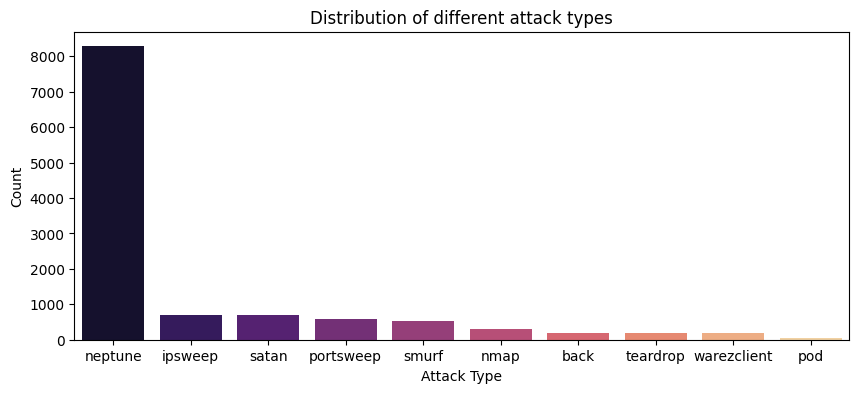

In [12]:
plt.figure(figsize=(10,4))
df_attacks=train["label"]
sns.countplot(x=df_attacks, order=df_attacks.value_counts().index[1:11], palette="magma")
plt.title("Distribution of different attack types")
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.show()

9. Label Encoding

In [13]:
def le(df):
  for col in df.columns:
    if df[col].dtype == 'object':
      label_encoder=LabelEncoder()
      df[col]=label_encoder.fit_transform(df[col])
le(train)
le(test)

In [14]:
train.drop(['num_outbound_cmds'],axis=1,inplace=True)
test.drop(['num_outbound_cmds'],axis=1,inplace=True)

In [15]:
print(f"Shape of training data after encoding: {train.shape}")
print(f"Shape of testing data after encoding: {test.shape}")

Shape of training data after encoding: (25192, 41)
Shape of testing data after encoding: (11850, 41)


In [16]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,1,19,9,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,11
1,0,2,41,9,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,11
2,0,1,46,5,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,9
3,0,1,22,9,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,11
4,0,1,22,9,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,11


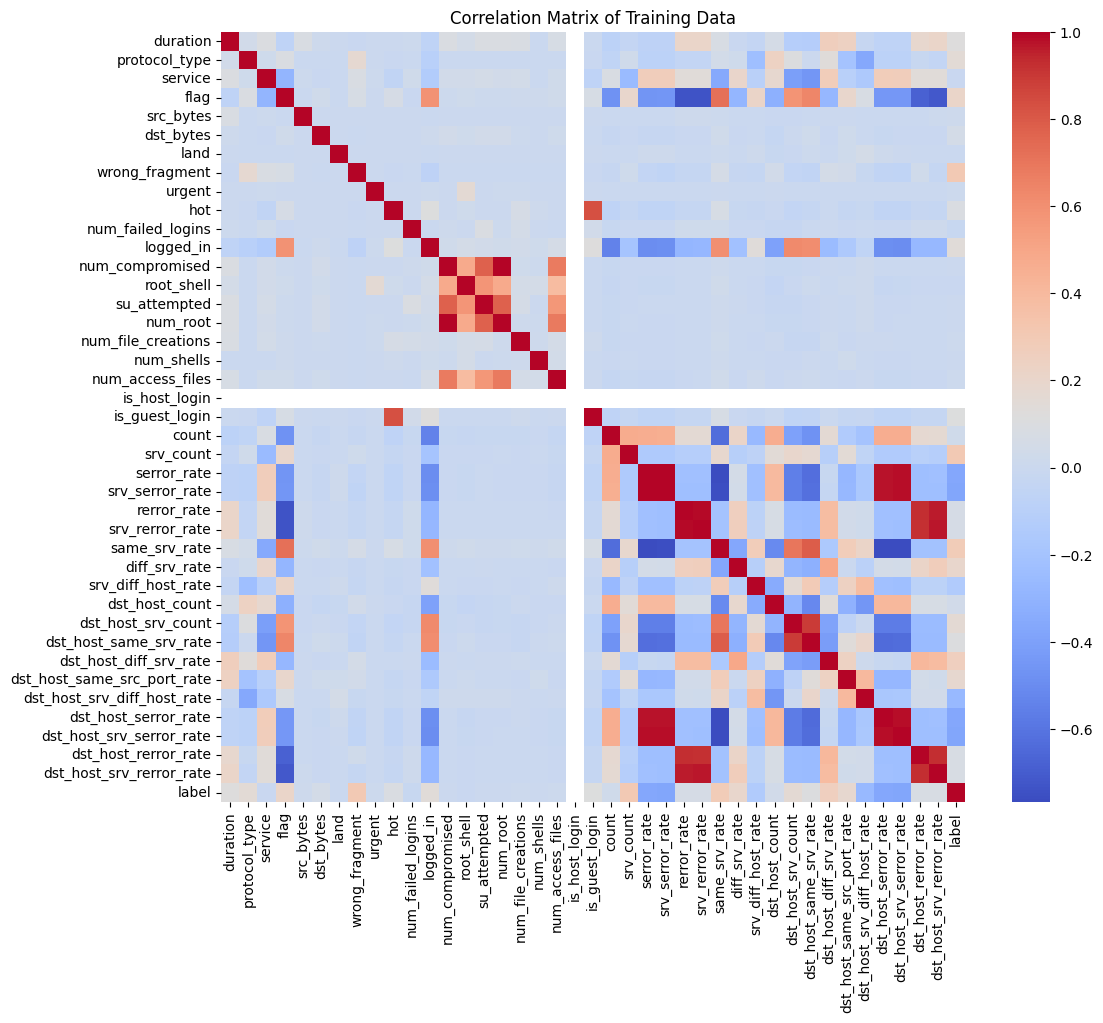

In [17]:
plt.figure(figsize=(12, 10))
sns.heatmap(train.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Matrix of Training Data')
plt.show()

10. Labels

In [18]:
X = train.drop(['label'], axis=1)
Y = train['label']

x_testing=test.drop(['label'],axis=1)
y_testing=test['label']

In [19]:
X.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,1,19,9,491,0,0,0,0,0,...,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00
1,0,2,41,9,146,0,0,0,0,0,...,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00
2,0,1,46,5,0,0,0,0,0,0,...,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00
3,0,1,22,9,232,8153,0,0,0,0,...,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01
4,0,1,22,9,199,420,0,0,0,0,...,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [20]:
Y.head()

,label
0,11
1,11
2,9
3,11
4,11


11. Scaling

In [21]:
scale=StandardScaler()
X=scale.fit_transform(X)

In [22]:
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(Y)
classes = np.unique(y_encoded)

12. Feature Selection

In [23]:
from sklearn.feature_selection import SelectKBest, f_classif
print("🔍 Performing hybrid feature selection...")

kbest = SelectKBest(score_func=f_classif, k=25)
X_kbest = kbest.fit_transform(X, y_encoded)
anova_idx = kbest.get_support(indices=True)

rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X, y_encoded)
rf_idx = np.argsort(rf_temp.feature_importances_)[-25:]

selected_idx = np.unique(np.concatenate((anova_idx, rf_idx)))
# Get the original column names from the training data before scaling
original_columns = train.drop(['label'], axis=1).columns
selected_features = original_columns[selected_idx]
X_selected = X[:, selected_idx]

print(f"✅ Selected Top {len(selected_features)} Features")

🔍 Performing hybrid feature selection...


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [19] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


✅ Selected Top 28 Features


13. Resampling using SMOTE

Class distribution before resampling:
Counter({np.int64(11): 13449, np.int64(9): 8282, np.int64(5): 710, np.int64(16): 691, np.int64(14): 587, np.int64(17): 529, np.int64(10): 301, np.int64(0): 196, np.int64(19): 188, np.int64(20): 181, np.int64(13): 38, np.int64(3): 10, np.int64(21): 7, np.int64(1): 6, np.int64(4): 5, np.int64(15): 4, np.int64(8): 2, np.int64(12): 2, np.int64(2): 1, np.int64(6): 1, np.int64(7): 1, np.int64(18): 1})
Class distribution after resampling:
Counter({11: 13449, 9: 13449, 20: 13449, 5: 13449, 14: 13449, 19: 13449, 10: 13449, 16: 13449, 17: 13449, 13: 13449, 0: 13449, 3: 13449, 8: 13449, 15: 13449, 1: 13449, 4: 13449, 21: 13449, 12: 13449})
Classes with a single sample in original data (excluded from SMOTE): [np.int64(2), np.int64(6), np.int64(7), np.int64(18)]


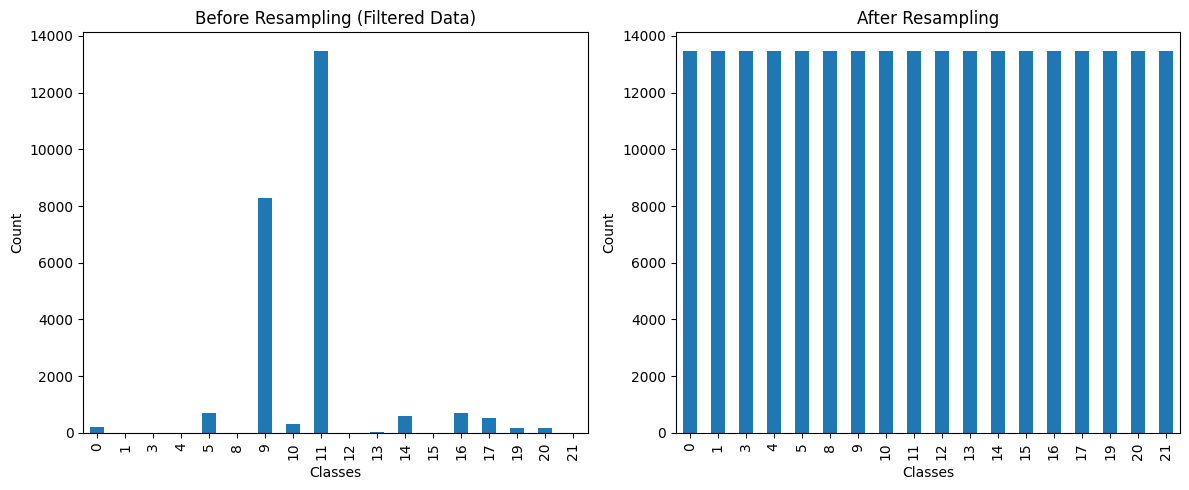

In [24]:
import pandas as pd
from collections import Counter
from imblearn.over_sampling import SMOTE, ADASYN
import matplotlib.pyplot as plt
import numpy as np # Import numpy for np.unique

# ----------------------------
# Assume X, y already defined (X_selected, y_encoded)
# ----------------------------

print("Class distribution before resampling:")
original_class_counts = Counter(y_encoded)
print(original_class_counts)

# Identify classes with only one sample in the original data
single_sample_classes_original = [label for label, count in original_class_counts.items() if count == 1]

# Determine the target number of samples for oversampling (majority class count in original data)
majority_class_count = max(original_class_counts.values())

# Define the sampling strategy: oversample all classes with more than one sample up to the majority class count
# Ensure the target count is not less than the original count for classes included in the strategy
sampling_strategy = {
    label: max(majority_class_count, count)  # Target is at least the original count, aiming for majority
    for label, count in original_class_counts.items()
    if count > 1 # Only include classes with more than one sample
}

# Convert y_encoded to a pandas Series to use the isin method
y_encoded_series = pd.Series(y_encoded)

# Filter X_selected and y_encoded to remove single-sample classes before applying SMOTE
# This aligns with the sampling_strategy which excludes single-sample classes
classes_to_keep = [label for label, count in original_class_counts.items() if count > 1]
mask_keep = y_encoded_series.isin(classes_to_keep)

X_filtered = X_selected[mask_keep]
y_encoded_filtered = y_encoded_series[mask_keep]

# Initialize resampled variables before the if block
X_resampled = X_filtered
y_resampled = y_encoded_filtered


# Instantiate SMOTE with the defined sampling strategy
# Determine a safe k_neighbors value based on the filtered data
# k_neighbors should be less than or equal to the number of samples in the smallest class being oversampled in the filtered data
min_filtered_minority_count = min([count for label, count in Counter(y_encoded_filtered).items() if label in sampling_strategy]) if sampling_strategy else 0
k_neighbors_value = min(5, max(1, min_filtered_minority_count - 1)) if min_filtered_minority_count > 1 else 1


if sampling_strategy and len(X_filtered) > 0: # Check if there are classes to oversample and data to process
    sm = SMOTE(random_state=42, sampling_strategy=sampling_strategy, k_neighbors=k_neighbors_value)

    X_resampled, y_resampled = sm.fit_resample(X_filtered, y_encoded_filtered)

    print("Class distribution after resampling:")
    print(Counter(y_resampled))
    print(f"Classes with a single sample in original data (excluded from SMOTE): {single_sample_classes_original}")

    # ----------------------------
    # Plot class distribution
    # ----------------------------
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Before resampling (using filtered data for a fairer comparison with resampled output)
    pd.Series(y_encoded_filtered).value_counts().sort_index().plot(kind='bar', ax=axes[0])
    axes[0].set_title("Before Resampling (Filtered Data)")
    axes[0].set_xlabel("Classes")
    axes[0].set_ylabel("Count")

    # After resampling
    pd.Series(y_resampled).value_counts().sort_index().plot(kind='bar', ax=axes[1])
    axes[1].set_title("After Resampling")
    axes[1].set_xlabel("Classes")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

else:
    print("No classes to oversample after excluding single-sample classes or no data to process.")
    # X_resampled and y_resampled are already initialized with filtered data

14. Validation Split

In [25]:
# Split the resampled and filtered data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled)

# Binarize y_test for multiclass ROC (using the classes from the resampled data)
classes_resampled = np.unique(y_resampled)
y_test_bin = label_binarize(y_test, classes=classes_resampled)

In [26]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((169457, 28), (72625, 28), (169457,), (72625,))

15. Model Training & Evaluation

▶ Training Logistic Regression
Training Time: 34.07s | Testing Time: 0.02s
Train Accuracy: 0.9828 | Test Accuracy: 0.9828
▶ Training Random Forest
Training Time: 50.84s | Testing Time: 1.07s
Train Accuracy: 1.0000 | Test Accuracy: 0.9996
▶ Training XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [13:55:39] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Time: 34.82s | Testing Time: 1.61s
Train Accuracy: 1.0000 | Test Accuracy: 0.9997

Summary of Model Performance

--- Logistic Regression ---

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4034
           1       0.97      1.00      0.98      4034
           3       1.00      1.00      1.00      4035
           4       1.00      1.00      1.00      4034
           5       0.98      0.99      0.98      4035
           8       1.00      0.99      1.00      4034
           9       1.00      1.00      1.00      4035
          10       0.96      0.98      0.97      4035
          11       0.95      0.82      0.88      4034
          12       0.97      1.00      0.98      4035
          13       1.00      1.00      1.00      4035
          14       0.99      1.00      0.99      4035
          15       0.99      1.00      1.00      4035
          16       0.95      0.95      0.95      4035
   

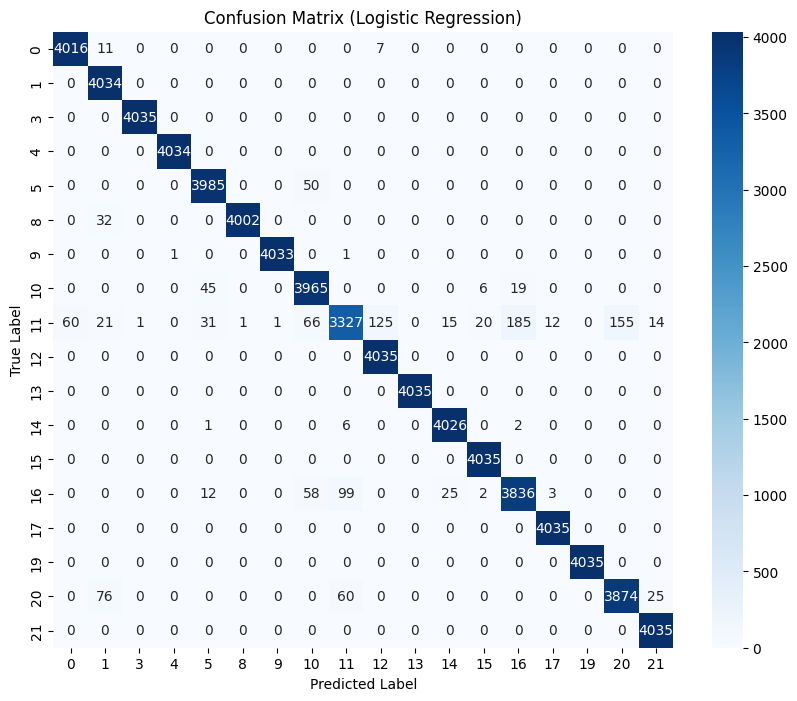


--- Random Forest ---

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4034
           1       1.00      1.00      1.00      4034
           3       1.00      1.00      1.00      4035
           4       1.00      1.00      1.00      4034
           5       1.00      1.00      1.00      4035
           8       1.00      1.00      1.00      4034
           9       1.00      1.00      1.00      4035
          10       1.00      1.00      1.00      4035
          11       1.00      1.00      1.00      4034
          12       1.00      1.00      1.00      4035
          13       1.00      1.00      1.00      4035
          14       1.00      1.00      1.00      4035
          15       1.00      1.00      1.00      4035
          16       1.00      1.00      1.00      4035
          17       1.00      1.00      1.00      4035
          19       1.00      1.00      1.00      4035
          20       1.0

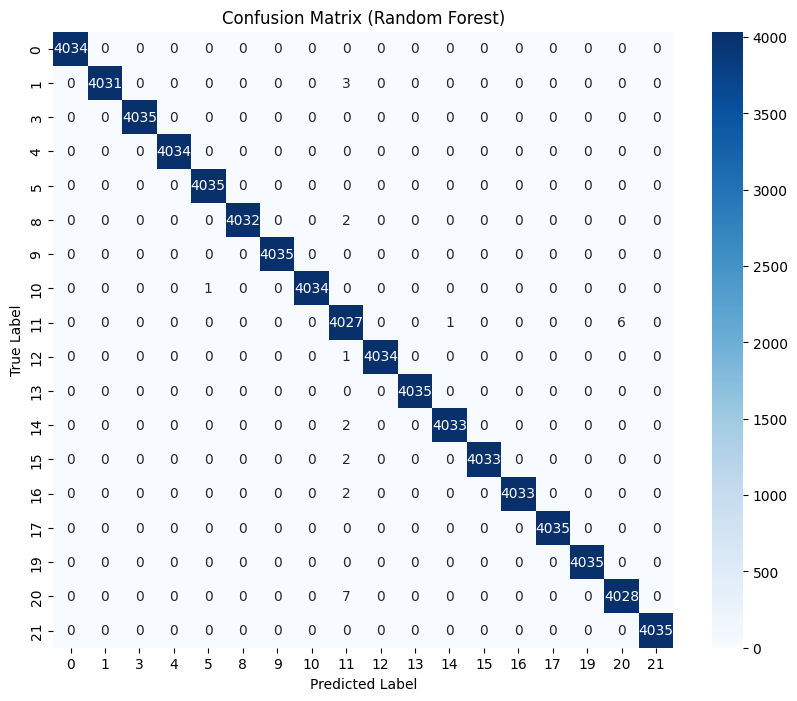


--- XGBoost ---

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4034
           1       1.00      1.00      1.00      4034
           3       1.00      1.00      1.00      4035
           4       1.00      1.00      1.00      4034
           5       1.00      1.00      1.00      4035
           8       1.00      1.00      1.00      4034
           9       1.00      1.00      1.00      4035
          10       1.00      1.00      1.00      4035
          11       1.00      1.00      1.00      4034
          12       1.00      1.00      1.00      4035
          13       1.00      1.00      1.00      4035
          14       1.00      1.00      1.00      4035
          15       1.00      1.00      1.00      4035
          16       1.00      1.00      1.00      4035
          17       1.00      1.00      1.00      4035
          19       1.00      1.00      1.00      4035
          20       1.00     

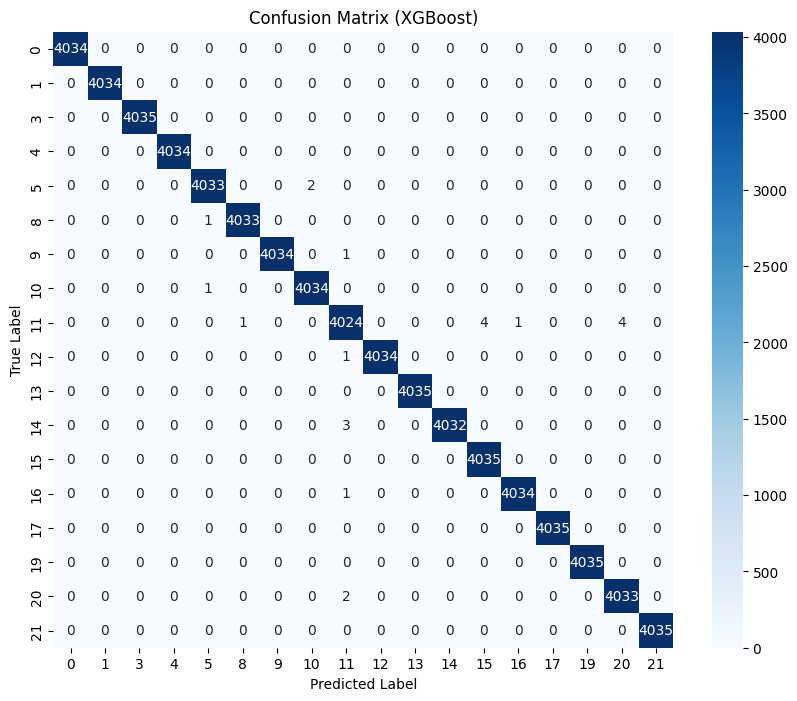

In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42),
}

results = {}

# Train all models
# Use the resampled data for training
# Use the resampled test data for evaluation as well
x_train_used = x_train
y_train_used = y_train
x_test_used = x_test
y_test_used = y_test


for name, model in models.items():
    print("="*60)
    print(f"▶ Training {name}")

    # Training time
    start = time.time()

    # Map the labels to a contiguous range for XGBoost if needed
    if name == "XGBoost":
        unique_labels = sorted(np.unique(y_train_used)) # Get unique labels and sort them
        label_map = {label: i for i, label in enumerate(unique_labels)}
        y_train_mapped = np.array([label_map[label] for label in y_train_used]) # Map the training labels
        model.fit(x_train_used, y_train_mapped)
    else:
        model.fit(x_train_used, y_train_used)

    train_time = time.time() - start

    # Training performance
    if name == "XGBoost":
        y_train_pred_mapped = model.predict(x_train_used)
        # Convert predictions back to original labels for evaluation
        reverse_label_map = {i: label for label, i in label_map.items()}
        y_train_pred = np.array([reverse_label_map[pred] for pred in y_train_pred_mapped])
    else:
        y_train_pred = model.predict(x_train_used)


    train_acc = accuracy_score(y_train_used, y_train_pred)

    # Testing time
    start = time.time()
    if name == "XGBoost":
        y_test_pred_mapped = model.predict(x_test_used)
        # Convert predictions back to original labels for evaluation
        reverse_label_map = {i: label for label, i in label_map.items()}
        y_test_pred = np.array([reverse_label_map[pred] for pred in y_test_pred_mapped])
    else:
        y_test_pred = model.predict(x_test_used)

    test_time = time.time() - start
    test_acc = accuracy_score(y_test_used, y_test_pred)

    # Store results
    results[name] = {
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Training Time": train_time,
        "Testing Time": test_time,
        "Confusion Matrix": confusion_matrix(y_test_used, y_test_pred),
        "Classification Report": classification_report(y_test_used, y_test_pred)
    }

    # Print results
    print(f"Training Time: {train_time:.2f}s | Testing Time: {test_time:.2f}s")
    print(f"Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}")

# After training, print classification reports and plot confusion matrices
print("\n" + "="*60)
print("Summary of Model Performance")
print("="*60)

for name, result in results.items():
    print(f"\n--- {name} ---")
    print("\nClassification Report (Test Data):")
    print(result["Classification Report"])

    # Confusion Matrix
    cm = result["Confusion Matrix"]
    plt.figure(figsize=(10, 8)) # Increased figure size for better readability
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=sorted(np.unique(y_test_used)),
                yticklabels=sorted(np.unique(y_test_used)))
    plt.title(f"Confusion Matrix ({name})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

16. Comparing the Models

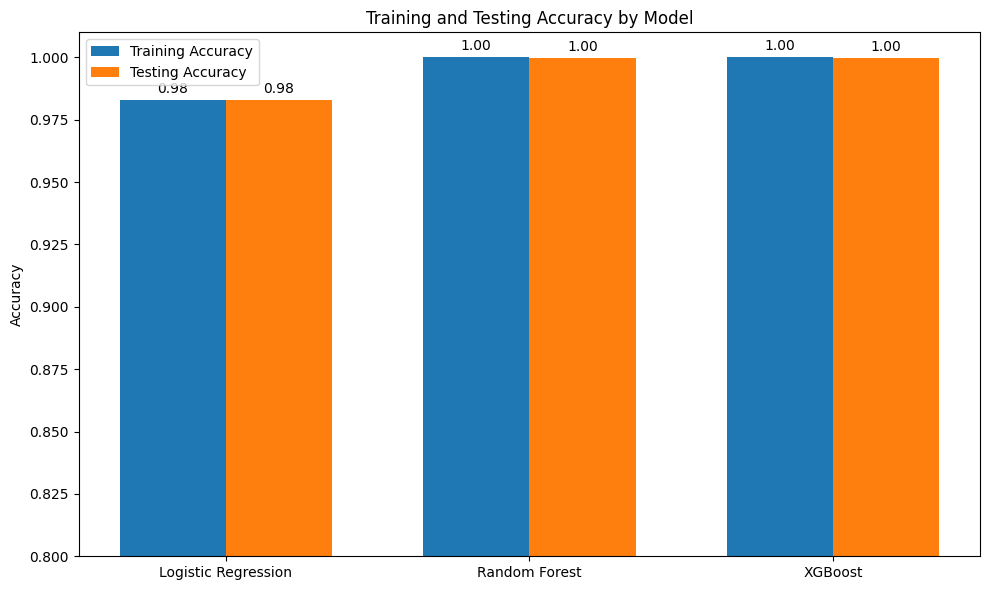

In [28]:
model_names = list(results.keys())
train_accuracy = [metrics['Train Accuracy'] for metrics in results.values()]
test_accuracy = [metrics['Test Accuracy'] for metrics in results.values()]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, train_accuracy, width, label='Training Accuracy')
rects2 = ax.bar(x + width/2, test_accuracy, width, label='Testing Accuracy')

ax.set_ylabel('Accuracy')
ax.set_title('Training and Testing Accuracy by Model')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('%.2f' % height,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.ylim(0.8, 1.01) # Adjust y-axis limits for better visualization
plt.tight_layout()
plt.show()

17. ROC-AUC Curve

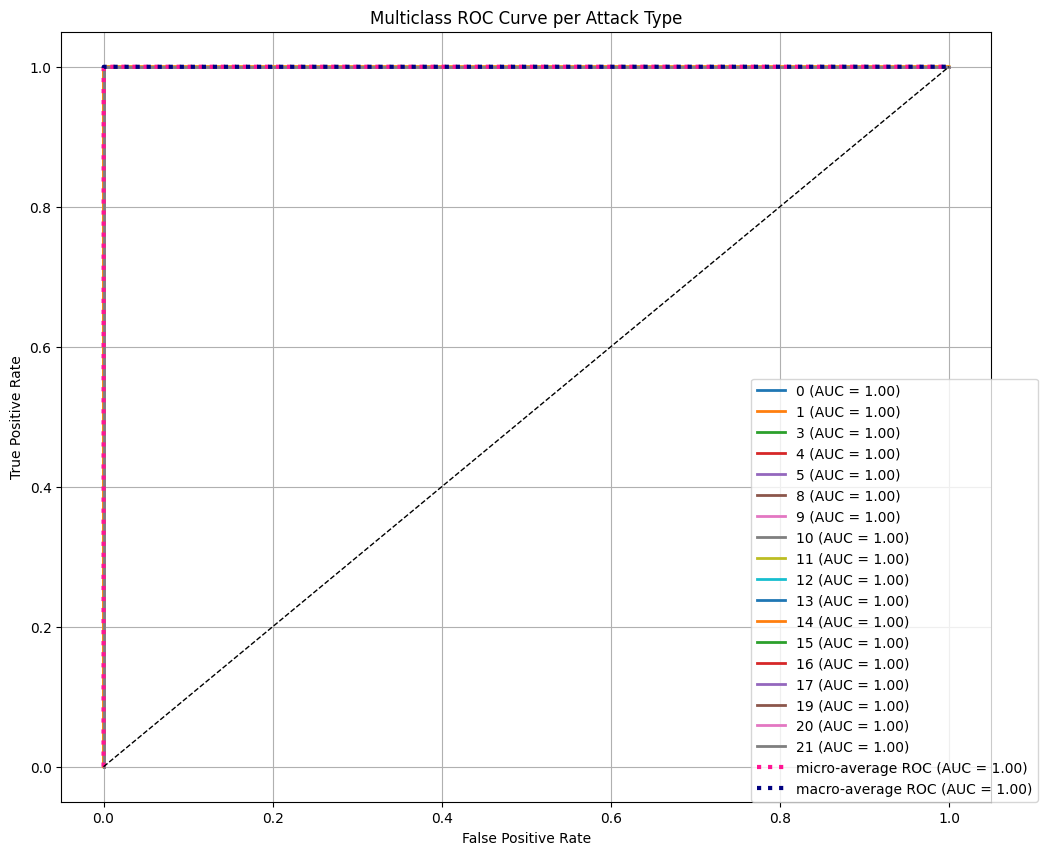

In [29]:
# ---------------------------
# 🧩 Multiclass ROC Per Attack Type
# ---------------------------
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize # Import label_binarize

# We'll use the Random Forest (best performing) for visualization
model = OneVsRestClassifier(RandomForestClassifier(n_estimators=200, random_state=42))

# Get the unique classes from the training data *after* splitting
classes_for_roc = np.unique(y_train)

# Binarize y_train using the classes present in y_train
y_train_bin = label_binarize(y_train, classes=classes_for_roc)

# Fit the OneVsRestClassifier
model.fit(x_train, y_train_bin)

# Get predicted probabilities for the test set
# Ensure the classes used for predict_proba are consistent with the classes the model was trained on
# OneVsRestClassifier's predict_proba output columns correspond to the order of classes it was fitted with
y_score = model.predict_proba(x_test)

# Binarize y_test for multiclass ROC using the same classes used for training/fitting
y_test_bin = label_binarize(y_test, classes=classes_for_roc)
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    # Ensure that the class index 'i' exists in both y_test_bin and y_score columns
    # If a class from classes_for_roc is not present in y_test, this might cause issues.
    # However, since y_test is a split of y_resampled_filtered which was stratified,
    # the classes should be consistent, assuming test_size is not 1 or 0.
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average ROC curve and ROC area
# Aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Interpolate all ROC curves
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Average and compute AUC
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# ---------------------------
# 🎨 Plotting ROC Curves
# ---------------------------
plt.figure(figsize=(12, 10)) # Adjusted figure size for potentially many classes

# Get original class names using the label encoder fitted on the original data
# Need to handle the case where classes_for_roc might not be in the original le_y mapping
original_class_names = []
for cls in classes_for_roc:
    try:
        original_class_names.append(le_y.inverse_transform([cls])[0])
    except ValueError:
        # Handle cases where a class in classes_for_roc might not be in the original le_y mapping
        original_class_names.append(f"Class {cls}") # Or handle as appropriate


# Plot per-class ROC
for i, class_name in enumerate(original_class_names):
    plt.plot(fpr[i], tpr[i],
             lw=2,
             label=f"{class_name} (AUC = {roc_auc[i]:.2f})")

# Plot micro and macro averages
plt.plot(fpr["micro"], tpr["micro"],
         label=f"micro-average ROC (AUC = {roc_auc['micro']:.2f})",
         color='deeppink', linestyle=':', linewidth=3)

plt.plot(fpr["macro"], tpr["macro"],
         label=f"macro-average ROC (AUC = {roc_auc['macro']:.2f})",
         color='navy', linestyle=':', linewidth=3)

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title("Multiclass ROC Curve per Attack Type")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", bbox_to_anchor=(1.05, 0), borderaxespad=0.) # Adjust legend position
plt.grid(True) # Add grid for better readability
plt.show()

18. Performance Metrics

In [30]:
# Calculate additional metrics and store in a DataFrame
performance_data = []
for name, result in results.items():
    # Calculate Sensitivity (Recall), Specificity, Precision, F1-score from the confusion matrix
    cm = result["Confusion Matrix"]
    TP = np.diag(cm)
    FP = cm.sum(axis=0) - TP
    FN = cm.sum(axis=1) - TP
    TN = cm.sum() - (TP + FP + FN)

    # Handle potential division by zero
    sensitivity = np.nanmean(TP / (TP + FN)) if (TP + FN).sum() > 0 else 0
    specificity = np.nanmean(TN / (TN + FP)) if (TN + FP).sum() > 0 else 0
    precision = np.nanmean(TP / (TP + FP)) if (TP + FP).sum() > 0 else 0
    f1_score = np.nanmean(2 * (precision * sensitivity) / (precision + sensitivity)) if (precision + sensitivity).sum() > 0 else 0


    performance_data.append({
        "Model": name,
        "Training Accuracy": result["Train Accuracy"],
        "Testing Accuracy": result["Test Accuracy"],
        "Sensitivity (Average)": sensitivity,
        "Specificity (Average)": specificity,
        "Precision (Average)": precision,
        "F1-score (Average)": f1_score,
    })

performance_df = pd.DataFrame(performance_data)
display(performance_df)

,Model,Training Accuracy,Testing Accuracy,Sensitivity (Average),Specificity (Average),Precision (Average),F1-score (Average)
0,Logistic Regression,0.982845,0.982816,0.982814,0.998989,0.982679,0.982747
1,Random Forest,0.999994,0.999628,0.999628,0.999978,0.999629,0.999629
2,XGBoost,0.999976,0.999697,0.999697,0.999982,0.999697,0.999697


19. Testing

In [31]:
# --- Testing with a single example ---
# The true labels are numerical (0-21), printing 'Attack'/'Normal' is misleading
# and likely relies on an unstated mapping (e.g., 0=normal, non-0=attack).
# We will use a more reliable index and print the actual numerical labels.

example_index = 4 # A random index likely to be one of the SMOTE-generated samples
example_data = x_test[example_index].reshape(1, -1)
true_label = y_test.iloc[example_index]

print(f"Example index: {example_index}")
print(f"True numerical label: {true_label}")
print("-" * 30)

# Make predictions with each model
for name, model in models.items():
    # Apply the same feature selection as done during training
    # Ensure the example_data is filtered by the selected features before prediction
    # Note: In a real deployment, you would load the scaler and selected_features
    # and apply them to new, raw data. Here, we are using a subset of x_test
    # which is already scaled and feature-selected, but this step demonstrates
    # the importance of using the correct features.
    # If you were using raw data here, you would first scale it, then apply feature selection.
    # Since x_test is already feature selected, we don't need to re-apply the filter here,
    # but the principle of using the correct features is crucial for new data.
    # The error message you received indicates that the prediction function expects
    # a certain number/set of features, which implies the data being fed to it
    # during prediction time in your application might be different.

    # For this test case, since x_test is already filtered, the prediction should work
    # if the models were trained on the same x_train (which they were).
    # The error likely occurs when trying to use these saved models on *new* raw data
    # without the correct preprocessing chain (scaling -> feature selection).

    # Let's simulate the process with the saved components for clarity in a real-world scenario:
    # Assuming you load 'nsl_multi_scaler.pkl' and 'nsl_multi_features.pkl'
    # loaded_scaler = joblib.load('nsl_multi_scaler.pkl')
    # loaded_features = joblib.load('nsl_multi_features.pkl')

    # # Example of how you would process *new raw data* (assuming it's in a pandas DataFrame 'new_raw_df')
    # # scaled_new_data = loaded_scaler.transform(new_raw_df)
    # # # Convert to DataFrame to easily select columns by name
    # # scaled_new_data_df = pd.DataFrame(scaled_new_data, columns=new_raw_df.columns)
    # # new_data_selected = scaled_new_data_df[loaded_features].values # Select only the important features and convert back to numpy array

    # For this notebook's demonstration with x_test, we don't need to re-scale or re-select features as x_test is already in the correct format.
    # The code below assumes the model was trained on feature-selected data and the prediction input (example_data) matches that format.

    prediction = model.predict(example_data)[0]

    # Handle XGBoost's mapped prediction
    if name == "XGBoost":
        # y_test_used was not mapped, so we need to map the prediction back
        # This requires access to the original label_map from the training cell (NWBbLjddLWnL)
        # In a real deployment, you might save this mapping or handle it differently.
        # For this notebook's context, we'll assume label_map is available from the previous cell execution.
        if 'label_map' in locals() or 'label_map' in globals():
             reverse_label_map = {i: label for label, i in label_map.items()}
             prediction = reverse_label_map.get(prediction, prediction) # Get original label or keep if not found
        else:
             print(f"Warning: label_map not found for {name}. Displaying raw prediction.")


    print(f"{name} Prediction: {prediction}")

Example index: 4
True numerical label: 20
------------------------------
Logistic Regression Prediction: 20
Random Forest Prediction: 20
XGBoost Prediction: 20


In [32]:
# --- Corrected Saving for Multi-class Model ---
import joblib
import pandas as pd
# Assuming 'train' is the original DataFrame with 41 columns (after dropping 'difficulty')
# The important step is that 'selected_features' from step 21 must be saved.

# 1. Save the trained models (assuming model training was correct)
joblib.dump(models["Logistic Regression"], 'nsl_multi_logreg.pkl')
joblib.dump(models["Random Forest"], 'nsl_multi_rf.pkl')
joblib.dump(models["XGBoost"], 'nsl_multi_xgb.pkl')

# 2. Save the scaler (which was fitted on all scaled data, X)
# This is usually okay, but the input data fed to it must be the 40 raw features first.
# Since the Streamlit GUI is collecting raw features, the current scaler is correct
# if the input dataframe for prediction is correctly filtered. Let's assume the
# scaled_input logic below is what matters for the model.
joblib.dump(scale, 'nsl_multi_scaler.pkl')

# 3. Save the CORRECT list of SELECTED feature names (from notebook step 21)
# You need to ensure you load and save the result of step 21's feature selection.
# Assuming you run this right after step 21:
joblib.dump(selected_features.tolist(), 'nsl_multi_features.pkl')

# 4. Save the LabelEncoder fitted on the training data labels
# This is needed to inverse transform the predicted numerical labels back to original names in the GUI
joblib.dump(le_y, 'nsl_multi_label_encoder.pkl')

# 5. Optionally save the mapping for XGBoost if needed for debugging or clarity in GUI
# This might not be strictly necessary if you are using the saved LabelEncoder,
# but can be helpful if you need to map back from the internally used contiguous labels.
if 'label_map' in locals() or 'label_map' in globals():
    joblib.dump(label_map, 'nsl_multi_xgboost_label_map.pkl')
    print("XGBoost label map saved.")
else:
    print("XGBoost label map not available in current scope, skipping save.")


print("Models, scaler, selected feature names, and label encoder saved successfully.")

XGBoost label map saved.
Models, scaler, selected feature names, and label encoder saved successfully.


The previous error "The feature names should match those that were passed during fit" indicates that the features used for prediction did not match the features the model was trained on. This can happen if the data is not preprocessed with the exact same steps (scaling and feature selection) before being fed to the saved model.

To fix this, when using the saved models for prediction on new data, ensure you:
1. Load the saved `nsl_multi_scaler.pkl` and apply it to your new raw data.
2. Load the saved `nsl_multi_features.pkl` to get the list of selected feature names.
3. Filter your scaled new data to include *only* these selected features, in the order they appear in the `nsl_multi_features.pkl` list.
4. Then, use this filtered data for prediction with the loaded models.

I've updated the saving cell (`TBrQyjdSFduZ`) to explicitly save the `LabelEncoder` used for the target variable, which will be helpful when converting the numerical predictions back to their original attack type names in your Streamlit GUI. I also added a check and save for the `label_map` used specifically by XGBoost, though the main `LabelEncoder` should suffice for general prediction output interpretation.